In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
print("TensorFlow:", tf.__version__)

(x_train, _), (_, _) = mnist.load_data()

x_train = x_train.astype("float32")
x_train = (x_train - 127.5) / 127.5
x_train = x_train.reshape(-1, 28, 28, 1)

print("Training data shape:", x_train.shape)

TensorFlow: 2.20.0
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28, 1)


In [2]:
generator = tf.keras.Sequential([
    layers.Dense(7 * 7 * 128, input_shape=(100,)),
    layers.LeakyReLU(0.2),
    layers.Reshape((7, 7, 128)),

    layers.Conv2DTranspose(64, 5, strides=2, padding="same"),
    layers.LeakyReLU(0.2),

    layers.Conv2DTranspose(1, 5, strides=2,
                           padding="same",
                           activation="tanh")
])
generator.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 6272)           │       633,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │       204,864 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 1)      │         1,601 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 839,937 (3.20 MB)

 Trainable params: 839,937 (3.20 MB)

 Non-trainable params: 0 (0.00 B)

In [3]:
discriminator = tf.keras.Sequential([
    layers.Conv2D(64, 5, strides=2, padding="same",
                  input_shape=(28, 28, 1)),
    layers.LeakyReLU(0.2),
    layers.Dropout(0.3),

    layers.Conv2D(128, 5, strides=2, padding="same"),
    layers.LeakyReLU(0.2),
    layers.Dropout(0.3),

    layers.Flatten(),
    layers.Dense(1, activation="sigmoid")
])
discriminator.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

Generated image shape: (1, 28, 28, 1)


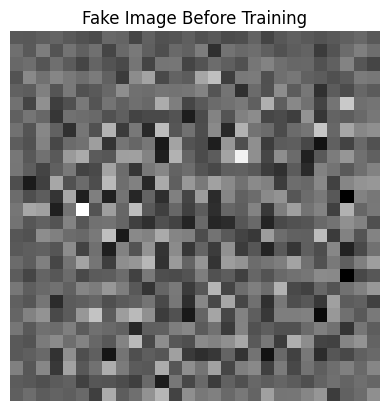

In [4]:
noise = tf.random.normal([1, 100])
fake_image = generator(noise, training=False)
print("Generated image shape:", fake_image.shape)
plt.imshow(fake_image[0, :, :, 0], cmap="gray")
plt.title("Fake Image Before Training")
plt.axis("off")
plt.show()

In [5]:
generator_optimizer = tf.keras.optimizers.Adam(0.0002)
discriminator_optimizer = tf.keras.optimizers.Adam(0.0002)

loss_function = tf.keras.losses.BinaryCrossentropy()

for epoch in range(5):
    noise = tf.random.normal([128, 100])
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        fake_images = generator(noise, training=True)
        real_output = discriminator(x_train[:128], training=True)
        fake_output = discriminator(fake_images, training=True)
        gen_loss = loss_function(
            tf.ones_like(fake_output),
            fake_output
        )
        disc_loss = (
            loss_function(tf.ones_like(real_output), real_output)
            +
            loss_function(tf.zeros_like(fake_output), fake_output)
        )
    gen_gradients = gen_tape.gradient(
        gen_loss,
        generator.trainable_variables
    )

    disc_gradients = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    generator_optimizer.apply_gradients(
        zip(gen_gradients, generator.trainable_variables)
    )

    discriminator_optimizer.apply_gradients(
        zip(disc_gradients, discriminator.trainable_variables)
    )

    print(
        "Epoch:", epoch + 1,
        "Generator Loss:", float(gen_loss),
        "Discriminator Loss:", float(disc_loss)
    )

Epoch: 1 Generator Loss: 0.6926759481430054 Discriminator Loss: 1.3539284467697144
Epoch: 2 Generator Loss: 0.69089674949646 Discriminator Loss: 1.2665678262710571
Epoch: 3 Generator Loss: 0.6881207823753357 Discriminator Loss: 1.1887011528015137
Epoch: 4 Generator Loss: 0.6840571165084839 Discriminator Loss: 1.119990587234497
Epoch: 5 Generator Loss: 0.6789754033088684 Discriminator Loss: 1.0587458610534668


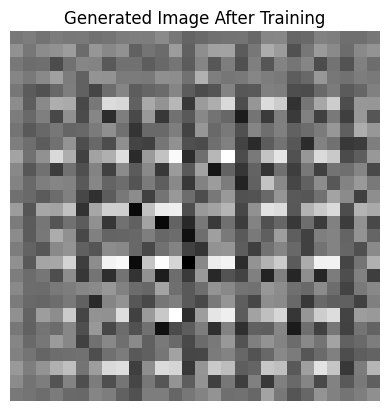

In [6]:
noise = tf.random.normal([1, 100])
generated_image = generator(noise, training=False)
plt.imshow(
    generated_image[0, :, :, 0],
    cmap="gray"
)
plt.title("Generated Image After Training")
plt.axis("off")
plt.show()